# Decoding MEG/EEG data

`Authors: Marijn van Vliet, Britta Westner, Alexandre Gramfort`


Let's see if we can do some _single trial_ decoding of our data (dataset #1)! 

For that, we will use the MNE-Python decoding module, which makes use of the extensive machine learning library and toolbox [scikit-learn](https://scikit-learn.org/stable/).

`
Reference:
Scikit-learn: Machine Learning in Python,
Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.
`

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import mne
import numpy as np

mne.set_log_level('error')

# Change the following path to where the folder ds000117 is on your disk.
data_path = "./ds000117_pruned"  # `./` means the folder of this notebook

# Change the following path to where you unzipped the extra data (`extra_meg_data-v2.zip`) on your disk.
extra_path = "./extra_data_mne"  # `./` means the folder of this notebook

## Load the epochs we saved

In [2]:
epochs_fname = f"{data_path}/derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss-epo.fif"
epochs = mne.read_epochs(epochs_fname)
epochs.crop(0, 0.4)
epochs.pick_types("grad")  # let's only keep the gradiometers this time

<EpochsFIF | 79 events (all good), 0 – 0.4 s (baseline -0.2 – 0 s (baseline period was cropped after baseline correction)), ~21.6 MiB, data loaded,
 'face/famous/first': 13
 'face/famous/immediate': 3
 'face/famous/long': 6
 'face/unfamiliar/first': 17
 'face/unfamiliar/immediate': 4
 'face/unfamiliar/long': 6
 'scrambled/first': 15
 'scrambled/immediate': 9
 'scrambled/long': 6>

Let's compute the ERFs and look at the contrast between _face_ and _scrambled_ responses.

In [3]:
evoked_face = epochs["face"].average()
evoked_scrambled = epochs["scrambled"].average()
evoked_contrast = mne.combine_evoked([evoked_face, evoked_scrambled], [0.5, -0.5])

Let's check the signal ...

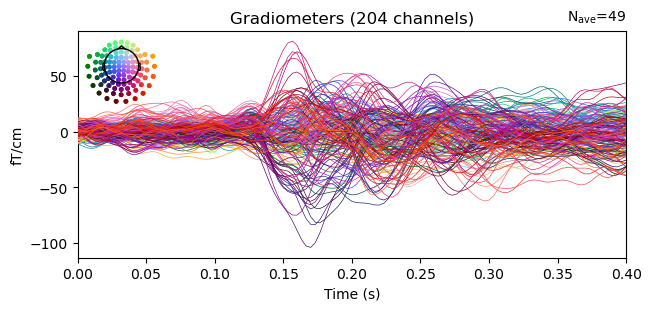

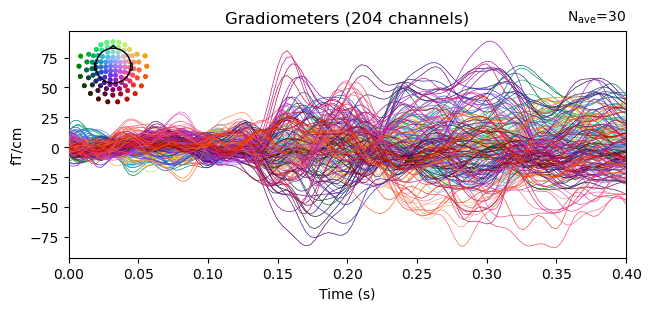

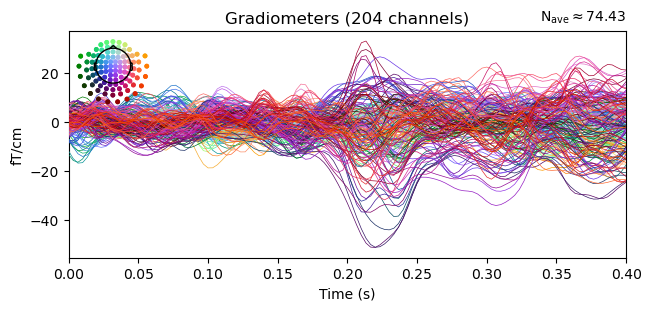

In [4]:
# Fit a sphere to the headshape in order to make proper topo plots.
# This is needed for this particular dataset and may not be necessary for yours.
radius, center, _ = mne.bem.fit_sphere_to_headshape(epochs.info, dig_kinds="eeg")
sphere = tuple(center) + (radius,)

evoked_face.plot(sphere=sphere);
evoked_scrambled.plot(sphere=sphere);
evoked_contrast.plot(sphere=sphere);

... and plot some topographies:

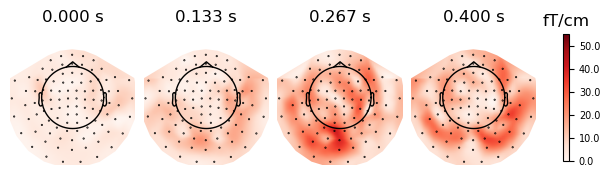

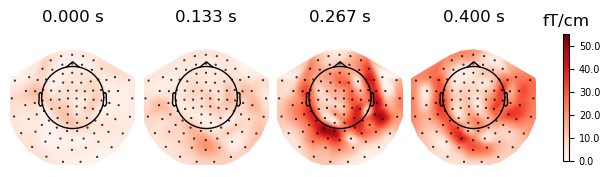

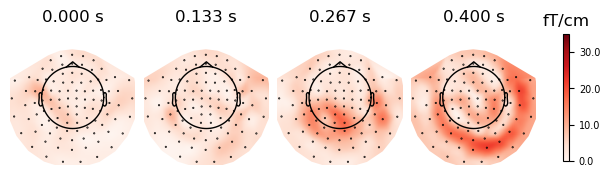

In [5]:
vmax = 55
evoked_face.plot_topomap(contours=0, vlim=(0, vmax), sphere=sphere);
evoked_scrambled.plot_topomap(contours=0, vlim=(0, vmax), sphere=sphere);

vmax = 35
evoked_contrast.plot_topomap(contours=0, vlim=(0, vmax), sphere=sphere);

## Let's prepare our data for classification

First, we equalize the trials per condition, so 50% is actually our chance level:

In [6]:
epochs.equalize_event_counts(["face", "scrambled"])

(<EpochsFIF | 60 events (all good), 0 – 0.4 s (baseline -0.2 – 0 s (baseline period was cropped after baseline correction)), ~18.1 MiB, data loaded,
  'face/famous/first': 7
  'face/famous/immediate': 3
  'face/famous/long': 4
  'face/unfamiliar/first': 10
  'face/unfamiliar/immediate': 3
  'face/unfamiliar/long': 3
  'scrambled/first': 15
  'scrambled/immediate': 9
  'scrambled/long': 6>,
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 39, 40, 53, 54, 63, 68, 75, 76,
        77, 78]))

For classification, we first need a _response_ vector. In our case, that is a vector that describes for each trial, whether the trial was 
a _face_ or a _scrambled_ trial. 

We set _face_ to 1, and _scrambled_ to 0.

In [7]:
# initialize with zeros and then set faces to 1
y = np.zeros(len(epochs.events), dtype=int)
y[epochs.events[:, 2] < 17] = 1  # 1 means face

y.size # check the length

60

We also need an array that contains our data (_observations x channels x time_):

In [8]:
X = epochs.get_data()
X.shape

(60, 204, 121)

## Let's see if we can classify the data based on single trials

In [9]:
# we use a logistic regression model and import this from scikit learn:
from sklearn.linear_model import LogisticRegression

# We then set the parameters (regularization value and solver):
logreg = LogisticRegression(C=1e6, solver='liblinear')

# We wrap the scikit-learn model in a mne.decoder.LinearModel class
# for extracting patterns later.
from mne.decoding import LinearModel
lm = LinearModel(logreg)

Let's use the `mne.decoding` module to manage our classification:

In [10]:
from sklearn.pipeline import make_pipeline
from mne.decoding import Scaler, Vectorizer, cross_val_multiscore

# We make a pipeline object that specifies how to handle the data:
clf = make_pipeline(Scaler(epochs.info),
                    Vectorizer(),
                    lm)

# Now let's run the classification and score based on a 5-fold-cross-validation:
scores = cross_val_multiscore(clf, X, y, cv=5, n_jobs=1)

# Let's compute the mean scores across cross-validation splits:
score = np.mean(scores, axis=0)
print(f"Spatio-temporal: {100 * score}%")

Spatio-temporal: 93.33333333333333%


## Visualizing filters and patterns

The `LinearModel` class of MNE-Python performs the Haufe transform on the linear model, giving us access to both the filters (=the regression coefficients) and the patterns. Let's pack them into MNE-Python objects and visualize them.

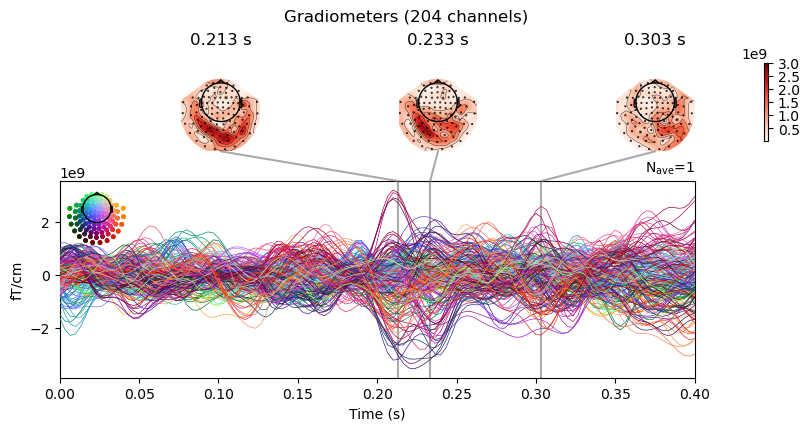

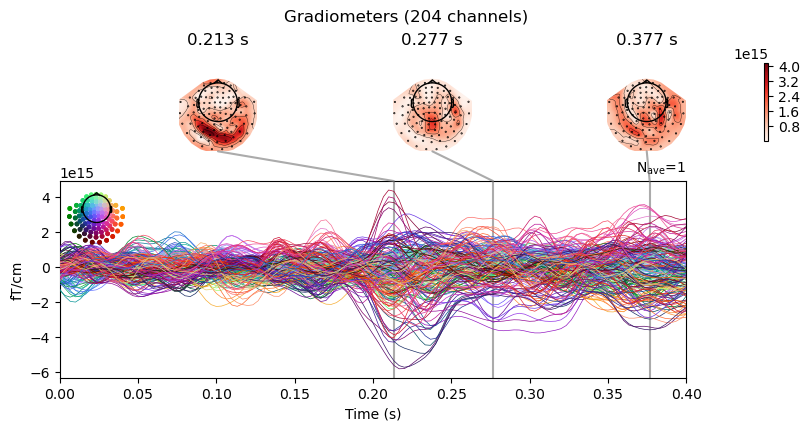

In [11]:
# Train the model of all data (no cross-validation)
clf.fit(X, y)

# Visualize the filters
filters = lm.filters_.reshape(len(epochs.ch_names), len(epochs.times))
filters = mne.EvokedArray(filters, epochs.info, tmin=epochs.times[0])
filters.plot_joint()

# Visualize the patterns
patterns = lm.patterns_.reshape(len(epochs.ch_names), len(epochs.times))
patterns = mne.EvokedArray(patterns, epochs.info, tmin=epochs.times[0])
patterns.plot_joint();

## Statistical testing

With accuracies >90% we can be pretty sure the model is performing better than chance. But let's formally test this against models with shuffled class labels that truly are performing at chance level.

In [17]:
from tqdm import trange

rng = np.random.default_rng(seed=1)

n = 100  # Numer of random models. Increase for better p-value estimation.
cv = 2  # Number of cross-validation folds. We decrease it here to save some time.
X_restricted = epochs.copy().crop(0.15, 0.25).get_data()  # restrict the data to save time.

random_scores = list()
y_random = y.copy()
for _ in trange(n):
    rng.shuffle(y_random)  # shuffles in-place
    score = cross_val_multiscore(clf, X_restricted, y_random, cv=cv, n_jobs=1).mean()
    random_scores.append(score)
random_scores = np.array(random_scores)

actual_score = cross_val_multiscore(clf, X_restricted, y, cv=cv, n_jobs=1).mean()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.49it/s]


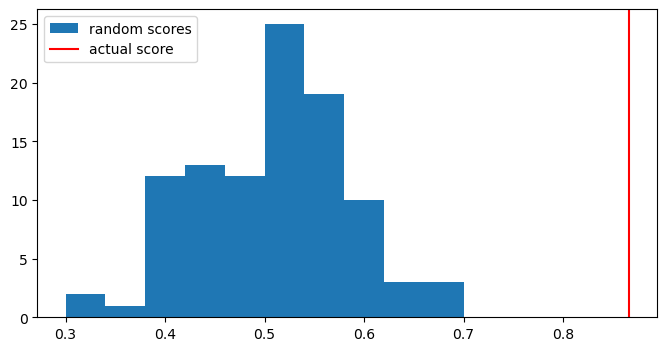

In [18]:
# Plot the distribution of random scores and annotate with the actual score.
plt.figure(figsize=(8, 4))
plt.hist(random_scores, label="random scores")
plt.axvline(actual_score, color="red", label="actual score")
plt.legend()

To compute a p-value, count the number of times a random model's performance exceeded our actual performance:

In [19]:
pvalue = (random_scores > actual_score).mean()
print("p-value:", pvalue)

p-value: 0.0


## Decoding over time

Often more interesting for electrophysiological data is to keep the time dimension and to slide
the decoding model across time:

In [54]:
from sklearn.preprocessing import StandardScaler
from mne.decoding import SlidingEstimator

# We prepare our pipeline again:
clf = make_pipeline(StandardScaler(), logreg)

# But now wrap this pipeline in a sliding estimator:
time_decod = SlidingEstimator(clf, n_jobs=1, scoring="roc_auc", verbose=True)

# Let's score it:
scores = cross_val_multiscore(time_decod, X, y, cv=5, n_jobs=1)

# Mean scores across cross-validation splits:
scores = np.mean(scores, axis=0)

# Let's see the dimesion of our scores:
scores.shape

(121,)

We kept the time dimension - by fitting one model per time-point. Let's plot our scores!

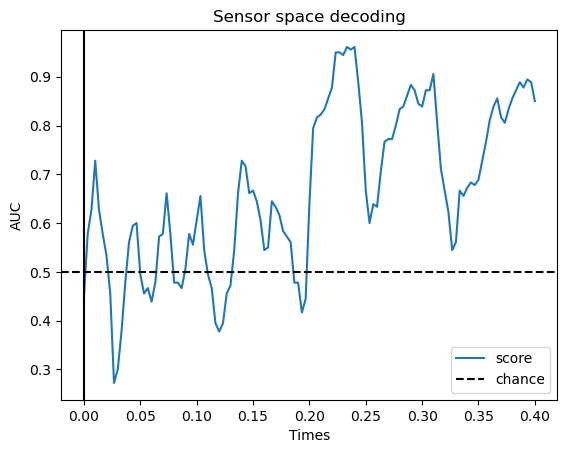

In [55]:
# prepare plot
fig, ax = plt.subplots()

# plot scores and chance level
ax.plot(epochs.times, scores, label="score")
ax.axhline(.5, color='k', linestyle="--", label="chance")
ax.axvline(.0, color='k', linestyle="-")  # mark time 0

# set axis labels, legend, title
ax.set_xlabel("Times")
ax.set_ylabel("AUC")  # Area Under the Curve
ax.legend()

ax.set_title("Sensor space decoding")

plt.show()

## Further reading

For more details see: https://mne.tools/stable/auto_tutorials/machine-learning/plot_sensors_decoding.html

and this book chapter:
```
Jean-Rémi King, Laura Gwilliams, Chris Holdgraf, Jona Sassenhagen, Alexandre Barachant, Denis Engemann, Eric Larson, Alexandre Gramfort. Encoding and Decoding Neuronal Dynamics: Methodological Framework to Uncover the Algorithms of Cognition. 2018. https://hal.archives-ouvertes.fr/hal-01848442/
```